Extended Data Figure 12 — CSC/Root clusters express a broader transcription factor repertoire across T-ALL samples.

(a) Number of DE TFs per cluster (red arrow = CSC/Root). (b) Top-50 CSC/Root TF dot plots. Patient 1 is Figure 3a,b. Colorbar / legend is omitted; cluster identity is the bar color and the red arrow.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import muon as mu

DATA = Path("PATH_TO_DATA")

mdata_bm4 = mu.read(DATA / "New_Analysis/TotalVI/New/BM4/TotalVI_BM4_TEAseq_CLEAN_TF.h5mu")
mdata_pb3 = mu.read(DATA / "New_Analysis/TotalVI/New/PB3/TotalVI_PB3_TEAseq_CLEAN_TF.h5mu")
mdata_bm5 = mu.read(DATA / "New_Analysis/TotalVI/New/BM5/TotalVI_BM5_TEAseq_CLEAN_TF.h5mu")
mdata_bm1 = mu.read(DATA / "New_Analysis/TotalVI/New/BM1/TotalVI_BM1_TEAseq_CLEAN_TF.h5mu")
mdata_bm3 = mu.read(DATA / "New_Analysis/TotalVI/New/BM3/TotalVI_BM3_TEAseq_CLEAN_TF.h5mu")


def plot_de_tf_detected_bar(df, adata_mvi, root, title="Number of DE TF Detected"):
    gene_columns = [c for c in df.columns if not str(c).startswith("Unnamed")]
    gene_counts = df[gene_columns].count()

    cl = adata_mvi.obs["Cluster_Final"]
    if not isinstance(cl.dtype, pd.CategoricalDtype):
        adata_mvi.obs["Cluster_Final"] = cl.astype(str).astype("category")
        cl = adata_mvi.obs["Cluster_Final"]

    categories = [str(c) for c in cl.cat.categories]
    colors = list(adata_mvi.uns["Cluster_Final_colors"])
    if len(colors) > len(categories):
        colors = colors[: len(categories)]
    cat2color = dict(zip(categories, colors))
    bar_colors = [cat2color[str(c)] for c in gene_columns]

    x = np.arange(len(gene_columns))
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.bar(
        x,
        gene_counts.values,
        color=bar_colors,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.9,
    )
    labels = [str(c) for c in gene_columns]
    if root in labels:
        i = labels.index(root)
        ax.annotate(
            "",
            xy=(i, gene_counts.values[i]),
            xytext=(i, gene_counts.values[i] + 0.08 * float(gene_counts.max())),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.4),
        )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Number of DE TFs")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


## BM4

### a — DE TF counts


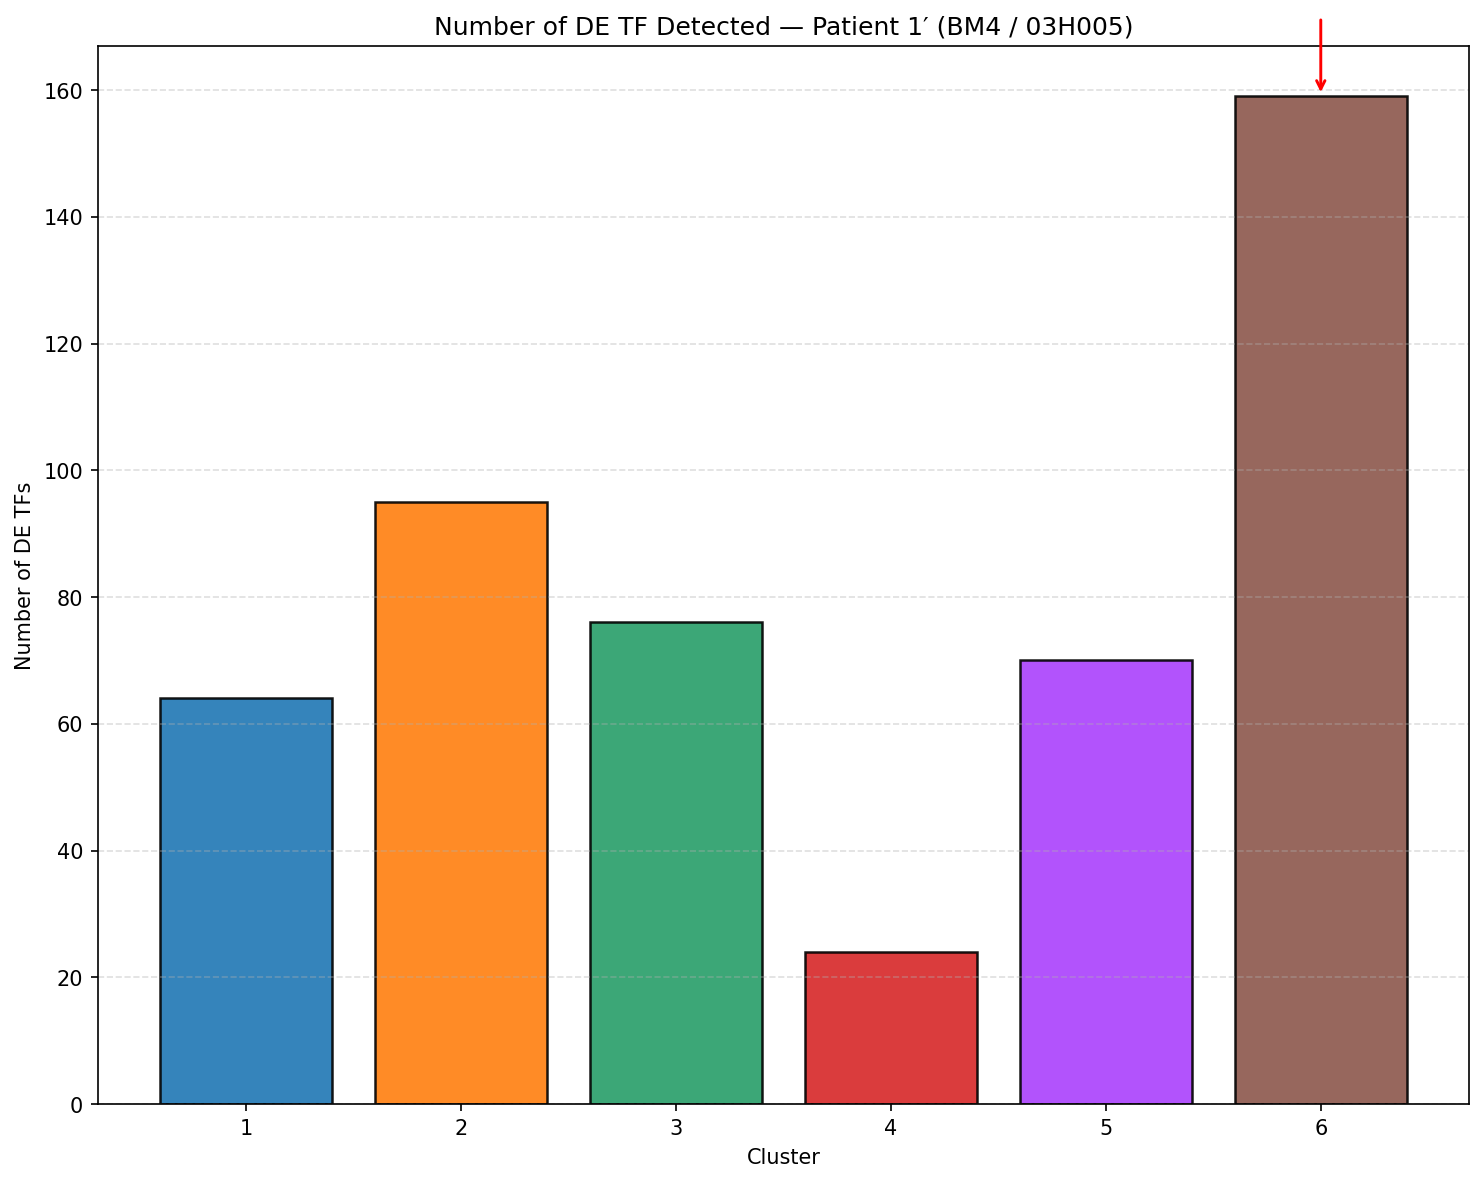

In [1]:
df = pd.read_csv(DATA / "New_Analysis/TotalVI/New/BM4/DE/filtered_rna.csv")
adata_mvi = sc.read_h5ad(DATA / "TALL_Website/Object/BM4/Teaseq_Multi_VI_BM4_Cleaned.h5ad")
plot_de_tf_detected_bar(df, adata_mvi, root="6", title="Number of DE TF Detected")


### b — CSC/Root TF dot plot


50 genes retained


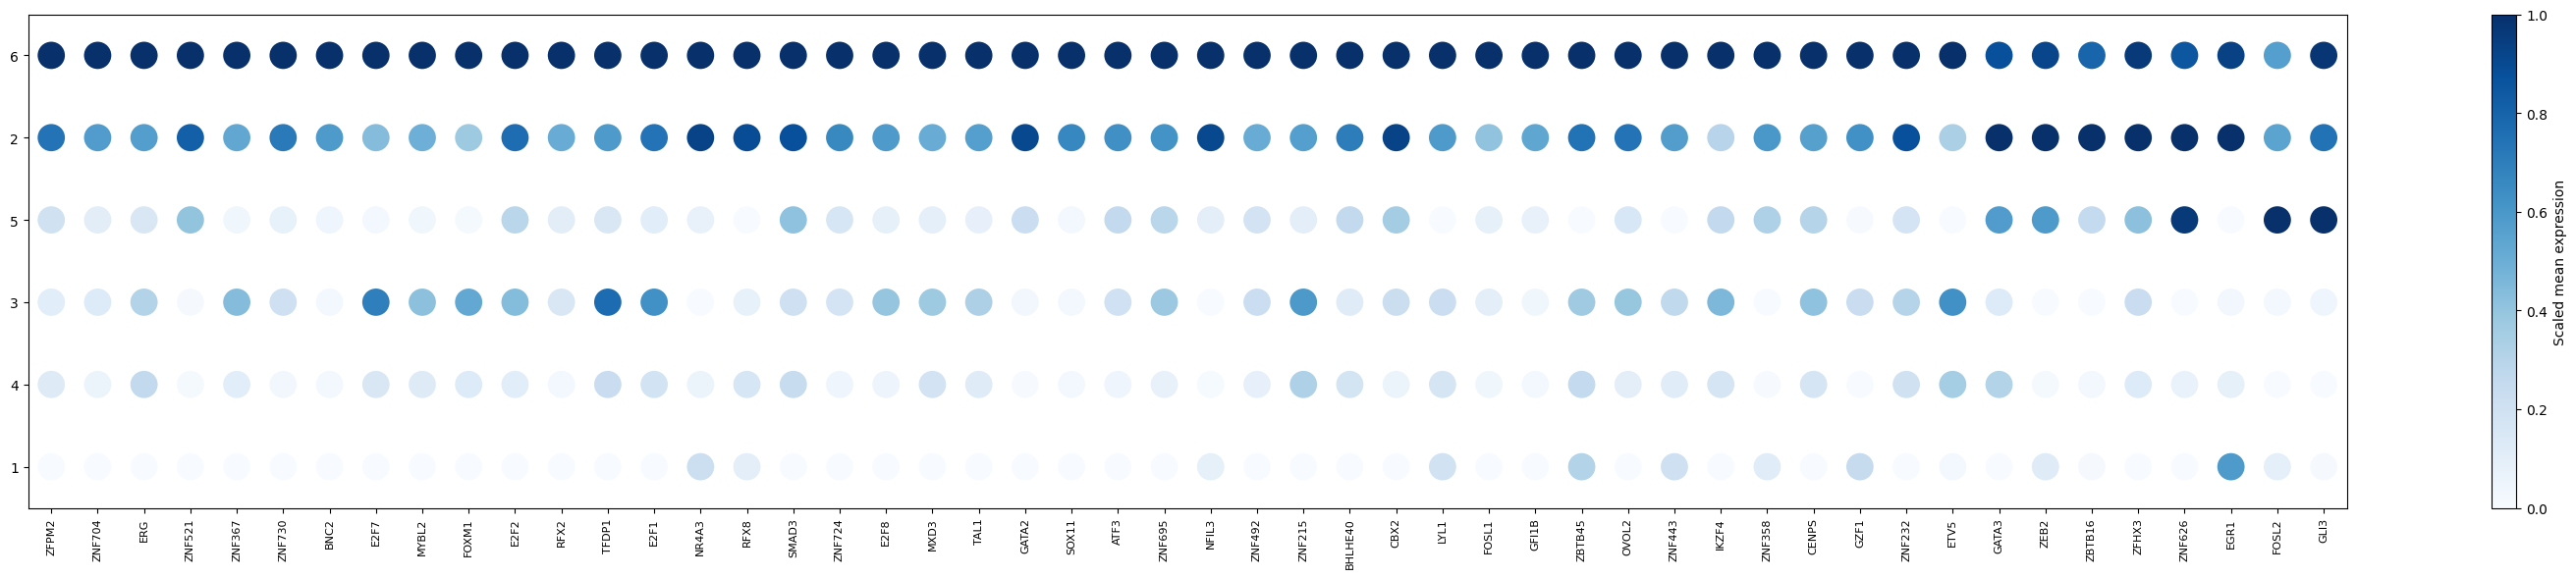

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- cluster order (trajectory, top → bottom on plot) ----
CLUSTER_ORDER = ["6", "2", "5", "3", "4", "1"]

# ---- load genes ----
filtered_rna_df = pd.read_csv(
    "PATH_TO_DATA/TotalVI/New/BM4/DE/filtered_rna.csv"
)

filtered_rna = {
    col: filtered_rna_df[col].dropna().tolist()
    for col in filtered_rna_df.columns
    if col != "Unnamed: 0"
}

# ---- BM4 TF program ----
genes_bm4 = [
    "ZNF521", "GATA2", "BNC2", "E2F8", "GFI1B", "NR4A3", "ZBTB16",
    "MYBL2", "SOX11", "GLI3", "ZFPM2", "ZNF695", "ZEB2", "ZNF704",
    "BHLHE40", "FOXM1", "TAL1", "E2F2", "ZNF358", "FOSL1", "ZNF626",
    "E2F7", "CENPS", "OVOL2", "NFIL3", "CBX2", "ZNF367", "MXD3",
    "ZNF232", "E2F1", "ZNF730", "LYL1", "ETV5", "ZNF215", "GZF1",
    "ZNF443", "FOSL2", "ZNF492", "ZNF724", "ATF3", "ZBTB45",
    "ZFHX3", "RFX2", "RFX8", "TFDP1", "ERG", "EGR1", "IKZF4",
    "SMAD3", "GATA3",
]

# ---- data ----
rna = mdata_bm4.mod["rna_subset"].copy()
rna.X = rna.layers["denoised_rna"]

# ---- keep ONLY genes present in BOTH lists AND dataset ----
genes = filtered_rna["6"]
genes = [g for g in genes if g in genes_bm4 and g in rna.var_names]

print(f"{len(genes)} genes retained")

# ---- matrix ----
X = rna[:, genes].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

groups = rna.obs["leiden_totalVI"].astype(str).values

df = pd.DataFrame(X, columns=genes)
df["group"] = groups

mean = df.groupby("group").mean()
pct = df.drop(columns="group").gt(0).groupby(df["group"]).mean()

# restrict + order clusters
clusters_present = [c for c in CLUSTER_ORDER if c in mean.index.astype(str)]
mean = mean.loc[clusters_present]
pct = pct.loc[clusters_present]

# Scanpy-style scaling
mean_scaled = (mean - mean.min()) / (mean.max() - mean.min() + 1e-9)

# ---- staircase gene order ----
cluster_to_idx = {c: i for i, c in enumerate(CLUSTER_ORDER)}
peak_cluster = mean[genes].idxmax(axis=0)

genes_ordered = sorted(
    genes,
    key=lambda g: (
        cluster_to_idx.get(str(peak_cluster[g]), len(CLUSTER_ORDER)),
        -float(mean.loc[peak_cluster[g], g]),
    ),
)

mean = mean[genes_ordered]
pct = pct[genes_ordered]
mean_scaled = mean_scaled[genes_ordered]

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(max(12, len(genes_ordered) * 0.6), 6))

x_pos = np.arange(len(genes_ordered))

for i, cluster in enumerate(clusters_present):
    ax.scatter(
        x_pos,
        np.full(len(x_pos), i),
        s=pct.loc[cluster].values * 400,
        c=mean_scaled.loc[cluster].values,
        cmap="Blues",
        vmin=0,
        vmax=1,
        edgecolors="none",
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(genes_ordered, rotation=90, fontsize=8)

ax.set_yticks(np.arange(len(clusters_present)))
ax.set_yticklabels(clusters_present)

ax.set_xlim(-0.5, len(genes_ordered) - 0.5)
ax.set_ylim(-0.5, len(clusters_present) - 0.5)
ax.invert_yaxis()  # cluster 6 at the top → diagonal staircase

plt.tight_layout()
plt.show()


## PB3

### a — DE TF counts


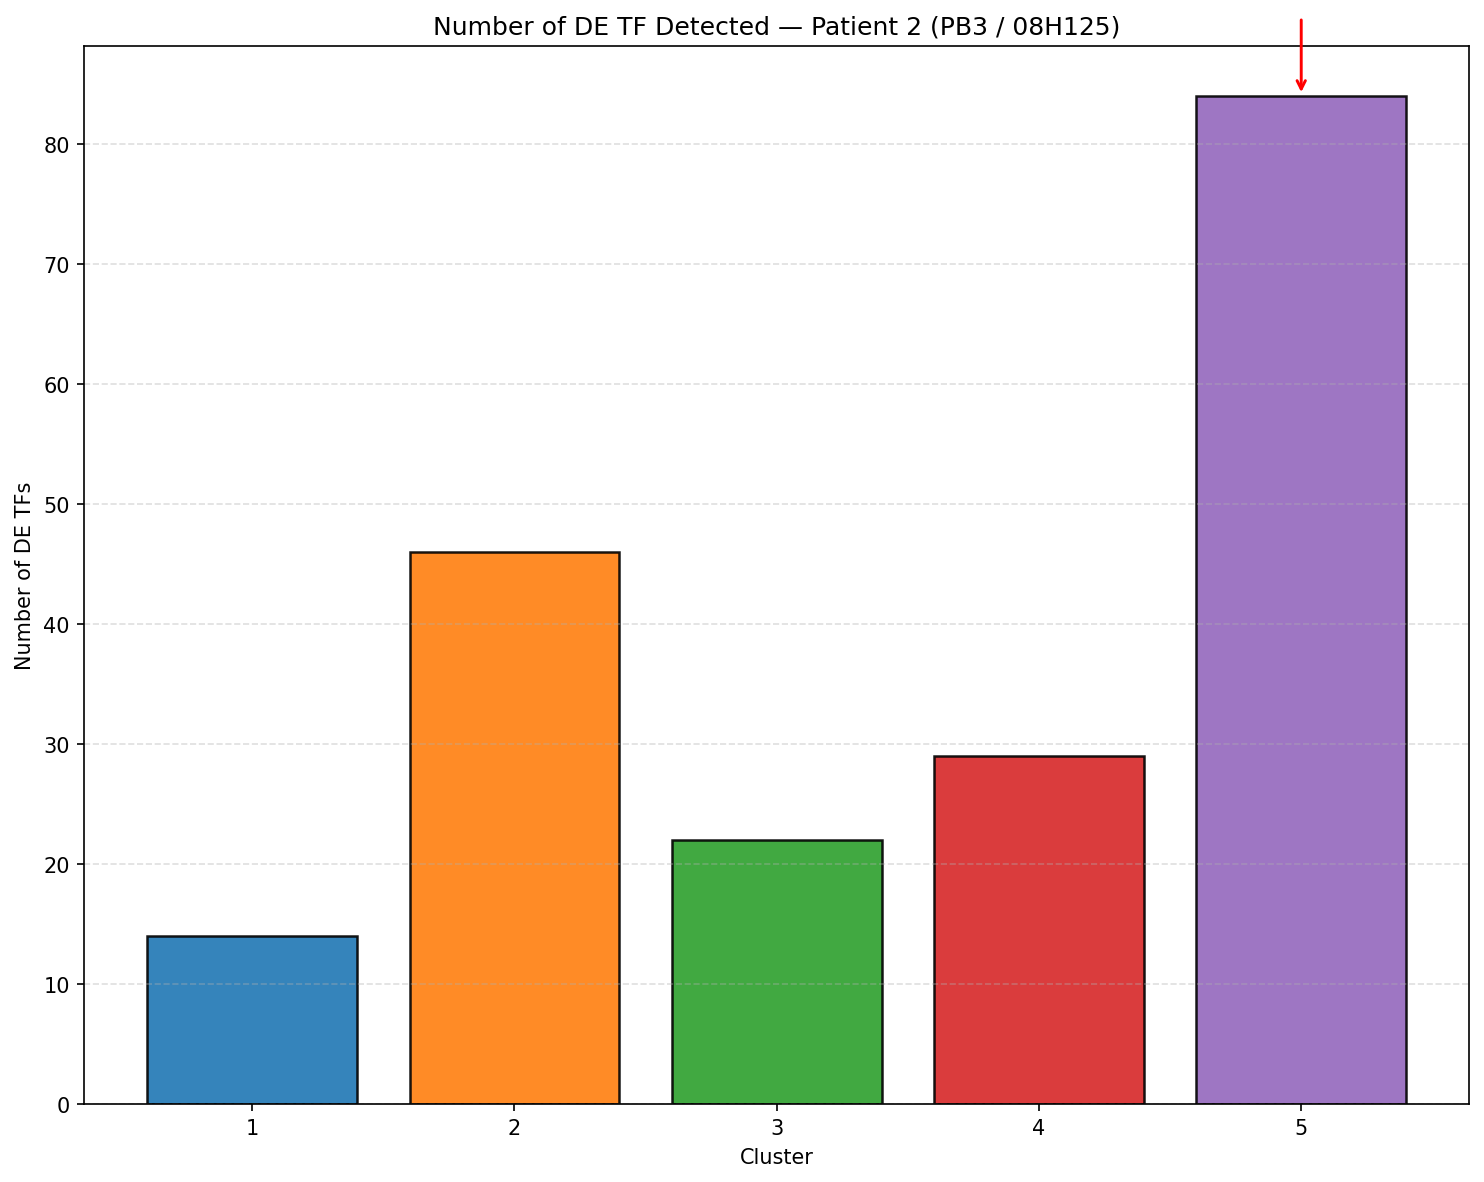

In [1]:
df = pd.read_csv(DATA / "New_Analysis/TotalVI/New/PB3/DE/filtered_rna.csv")
adata_mvi = sc.read_h5ad(DATA / "New_Analysis/MultiVI/PB3/Teaseq_Multi_VI_PB3_Cleaned.h5ad")
plot_de_tf_detected_bar(df, adata_mvi, root="5", title="Number of DE TF Detected")


### b — CSC/Root TF dot plot


49 genes retained


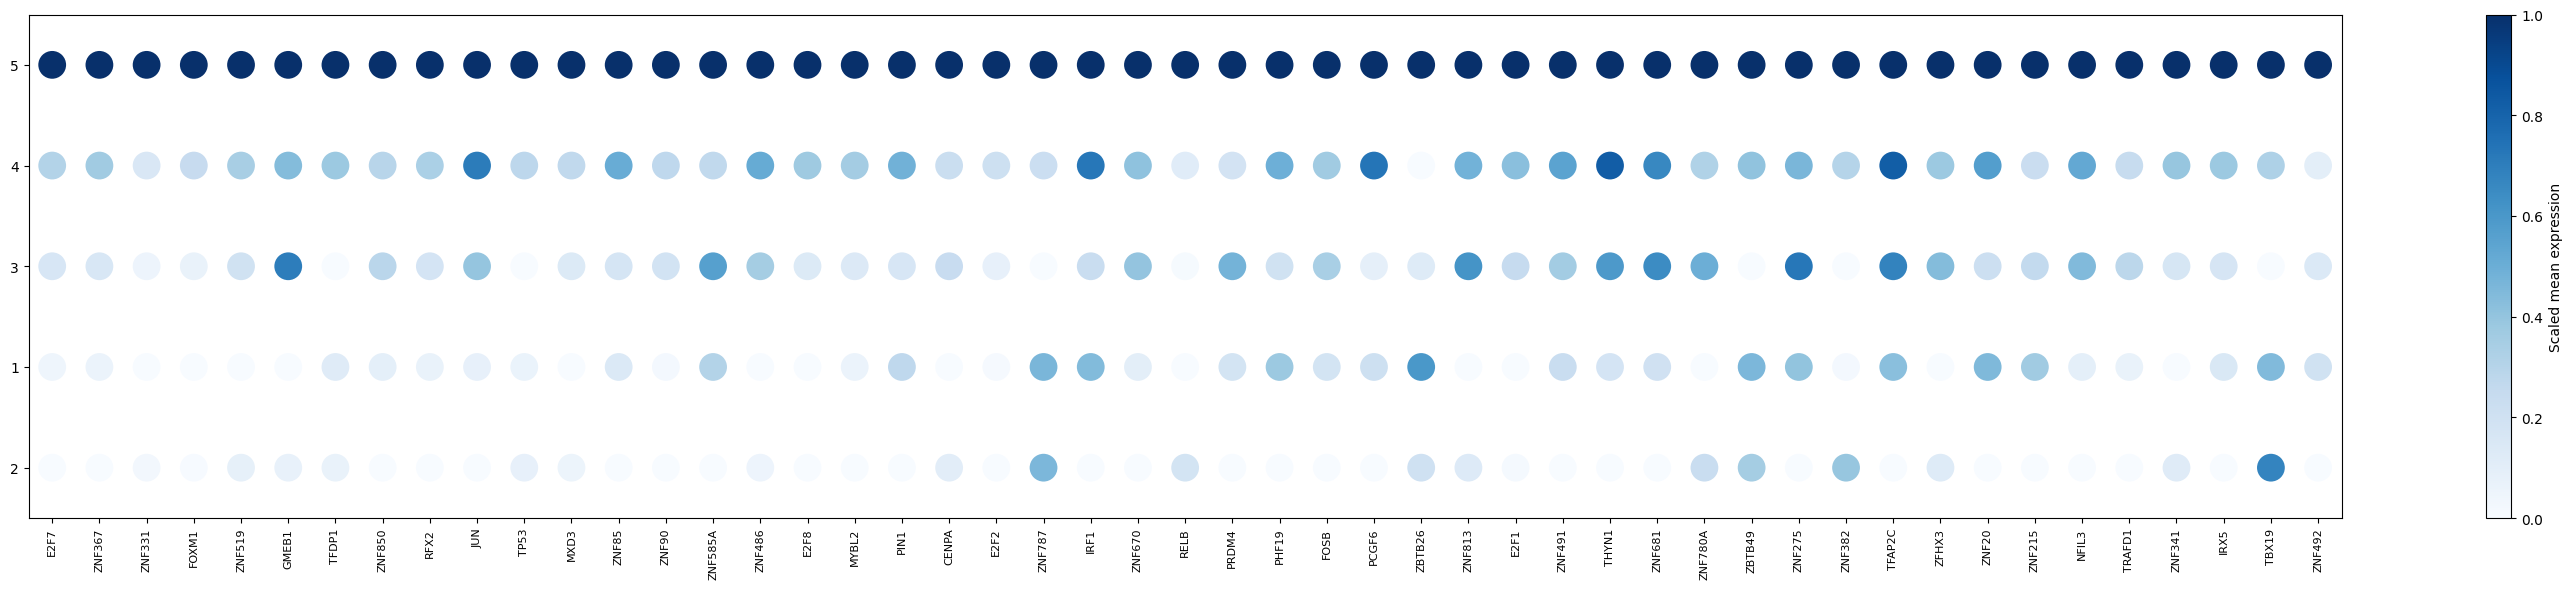

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- cluster order (trajectory, top → bottom on plot) ----
CLUSTER_ORDER = ["5", "4", "3", "1", "2"]

# ---- load genes ----
filtered_rna_df = pd.read_csv(
    "PATH_TO_DATA/TotalVI/New/PB3/DE/filtered_rna.csv"
)

filtered_rna = {
    col: filtered_rna_df[col].dropna().tolist()
    for col in filtered_rna_df.columns
    if col != "Unnamed: 0"
}

# ---- PB3 TF program ----
genes_pb3 = [
    "E2F8", "E2F7", "MYBL2", "E2F2", "FOXM1", "RFX2", "E2F1",
    "FOSB", "CENPA", "MXD3", "ZNF367", "ZNF492", "ZNF331",
    "ZNF850", "ZFHX3", "ZNF681", "NFIL3", "ZNF341", "ZNF85",
    "ZNF90", "ZNF215", "IRX5", "ZNF519", "ZNF275", "TBX19",
    "TP53", "PHF19", "TFDP1", "THYN1", "JUN", "IRF1", "SPI1",
    "PIN1", "ZNF780A", "PRDM4", "TFAP2C", "RELB", "ZBTB49",
    "ZNF813", "GMEB1", "ZNF670", "ZNF491", "ZNF787", "PCGF6",
    "ZNF382", "ZNF20", "ZBTB26", "ZNF585A", "TRAFD1", "ZNF486",
]

# ---- data ----
rna = mdata_pb3.mod["rna_subset"].copy()
rna.X = rna.layers["denoised_rna"]

# ---- keep ONLY genes present in BOTH lists AND dataset ----
genes = filtered_rna["5"]
genes = [g for g in genes if g in genes_pb3 and g in rna.var_names]

print(f"{len(genes)} genes retained")

# ---- matrix ----
X = rna[:, genes].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

groups = rna.obs["leiden_totalVI"].astype(str).values

df = pd.DataFrame(X, columns=genes)
df["group"] = groups

mean = df.groupby("group").mean()
pct = df.drop(columns="group").gt(0).groupby(df["group"]).mean()

# restrict + order clusters
clusters_present = [c for c in CLUSTER_ORDER if c in mean.index.astype(str)]
mean = mean.loc[clusters_present]
pct = pct.loc[clusters_present]

# Scanpy-style scaling
mean_scaled = (mean - mean.min()) / (mean.max() - mean.min() + 1e-9)

# ---- staircase gene order ----
cluster_to_idx = {c: i for i, c in enumerate(CLUSTER_ORDER)}
peak_cluster = mean[genes].idxmax(axis=0)

genes_ordered = sorted(
    genes,
    key=lambda g: (
        cluster_to_idx.get(str(peak_cluster[g]), len(CLUSTER_ORDER)),
        -float(mean.loc[peak_cluster[g], g]),
    ),
)

mean = mean[genes_ordered]
pct = pct[genes_ordered]
mean_scaled = mean_scaled[genes_ordered]

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(max(12, len(genes_ordered) * 0.6), 6))

x_pos = np.arange(len(genes_ordered))

for i, cluster in enumerate(clusters_present):
    ax.scatter(
        x_pos,
        np.full(len(x_pos), i),
        s=pct.loc[cluster].values * 400,
        c=mean_scaled.loc[cluster].values,
        cmap="Blues",
        vmin=0,
        vmax=1,
        edgecolors="none",
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(genes_ordered, rotation=90, fontsize=8)

ax.set_yticks(np.arange(len(clusters_present)))
ax.set_yticklabels(clusters_present)

ax.set_xlim(-0.5, len(genes_ordered) - 0.5)
ax.set_ylim(-0.5, len(clusters_present) - 0.5)
ax.invert_yaxis()  # cluster 5 at the top → diagonal staircase

plt.tight_layout()
plt.show()


## BM5

### a — DE TF counts


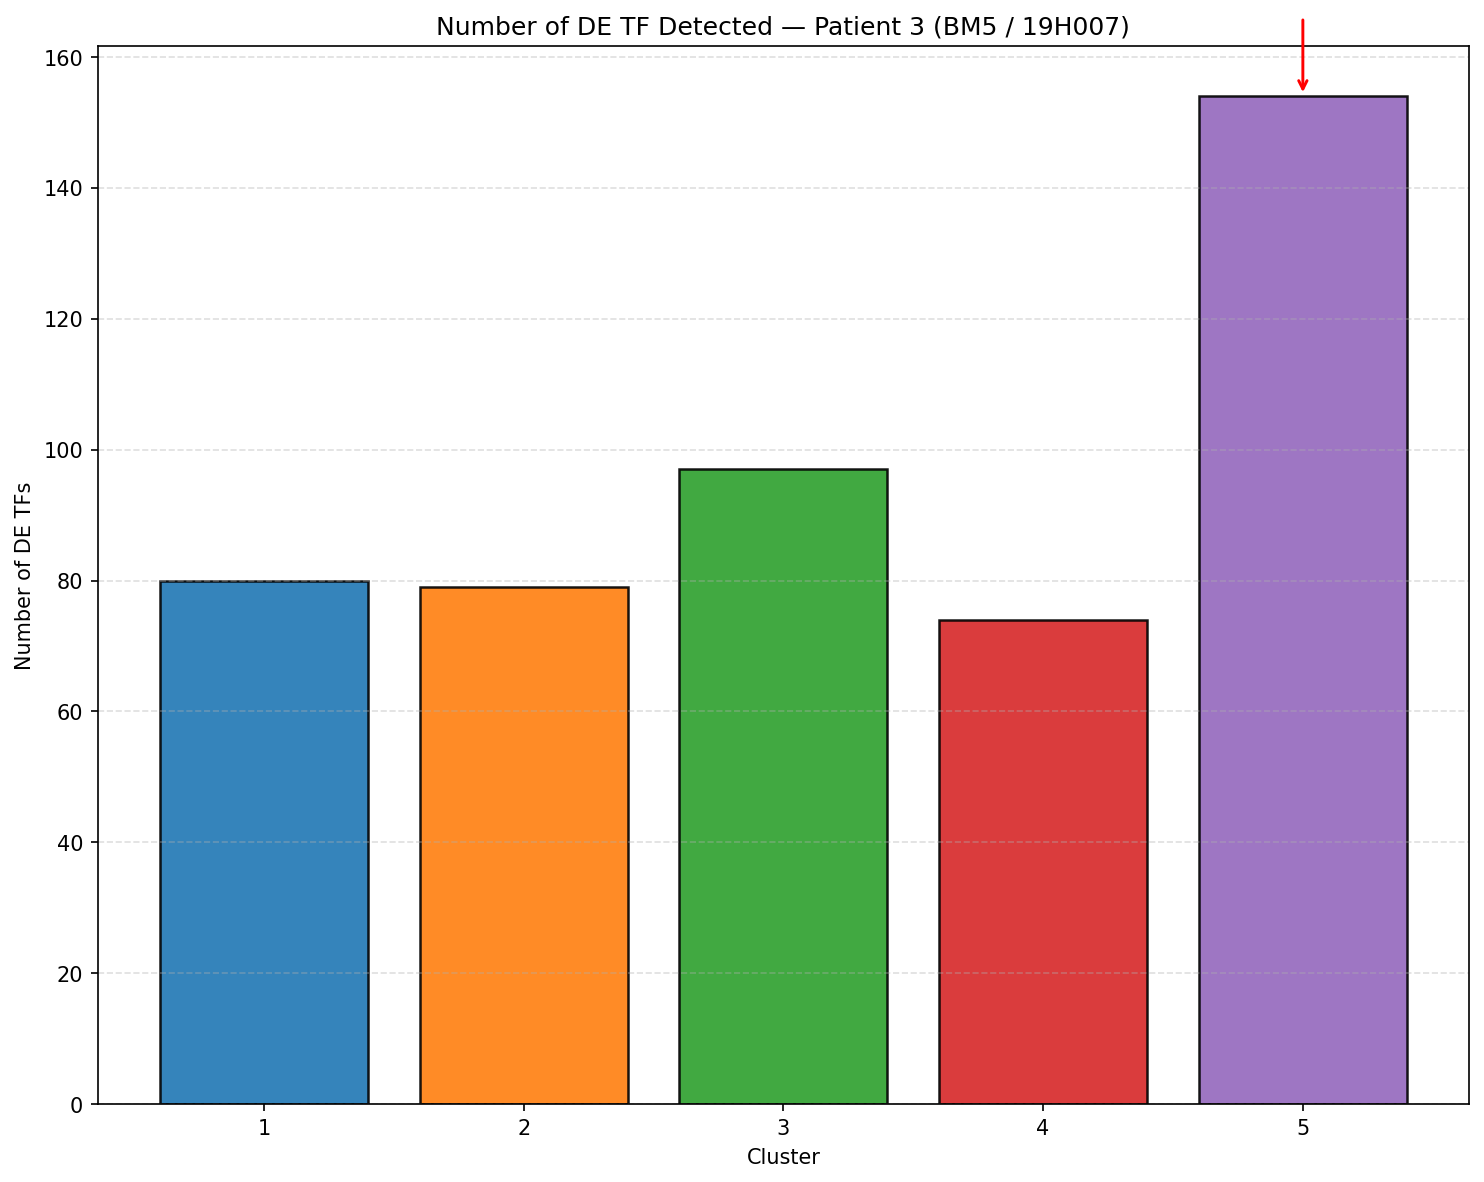

In [1]:
df = pd.read_csv(DATA / "New_Analysis/TotalVI/New/BM5/DE/filtered_rna.csv")
adata_mvi = sc.read_h5ad(DATA / "New_Analysis/Scenicplus/New_BM5/Teaseq_Multi_VI_BM5_Cleaned.h5ad")
plot_de_tf_detected_bar(df, adata_mvi, root="5", title="Number of DE TF Detected")


### b — CSC/Root TF dot plot


50 genes retained


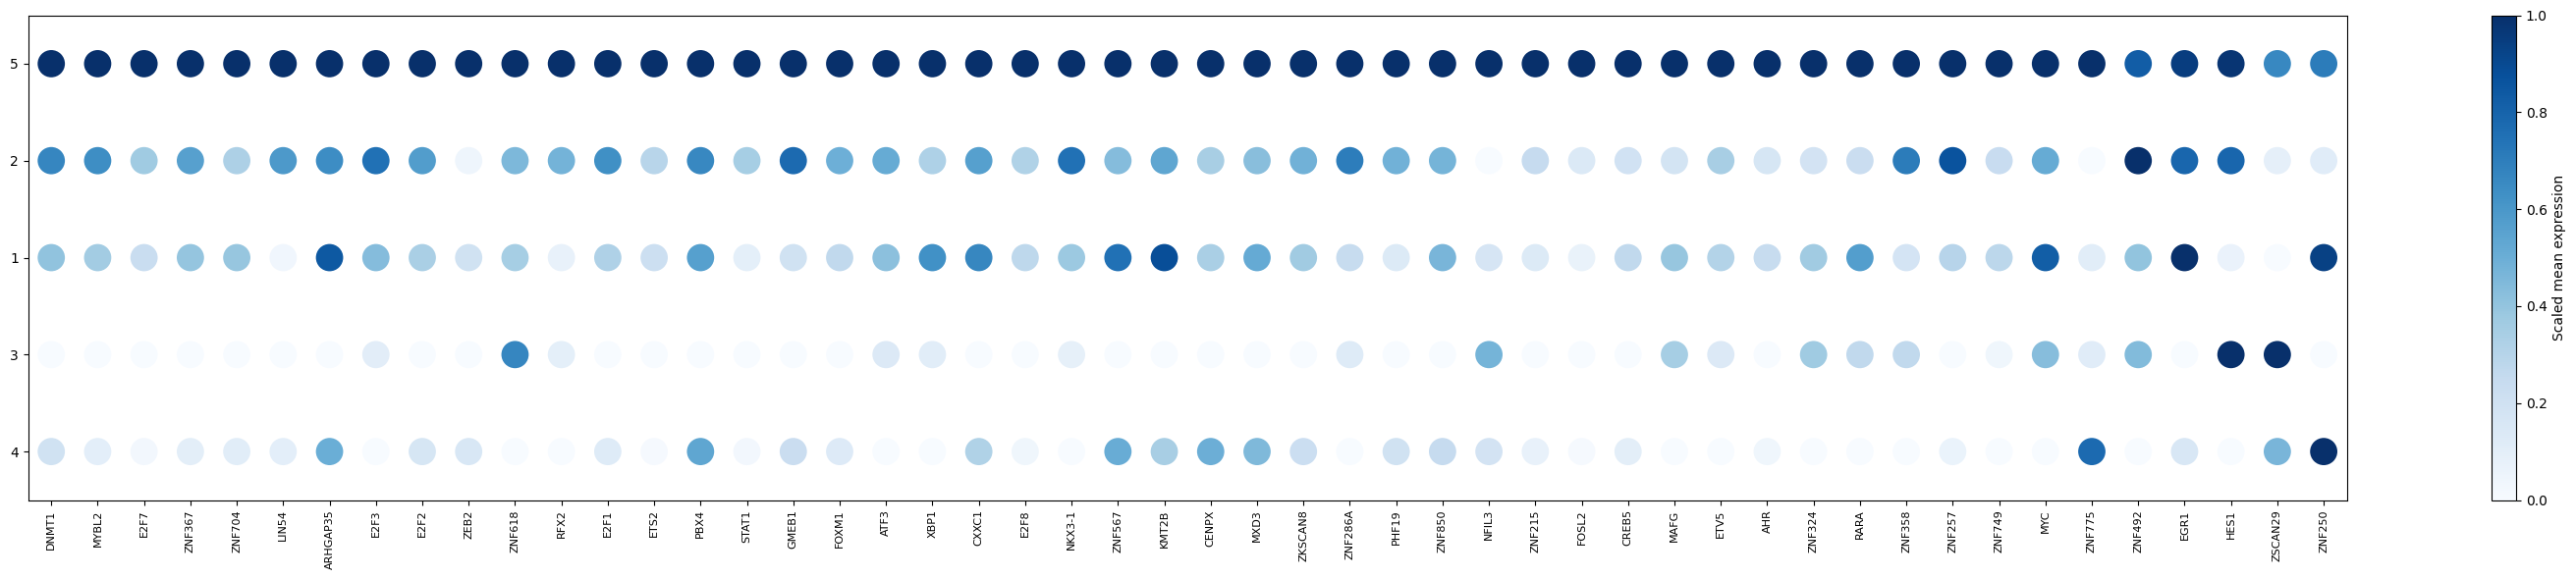

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- cluster order (trajectory, top → bottom on plot) ----
CLUSTER_ORDER = ["5", "2", "1", "3", "4"]

# ---- load genes ----
filtered_rna_df = pd.read_csv(
    "PATH_TO_DATA/TotalVI/New/BM5/DE/filtered_rna.csv"
)

filtered_rna = {
    col: filtered_rna_df[col].dropna().tolist()
    for col in filtered_rna_df.columns
    if col != "Unnamed: 0"
}

# ---- BM5 TF program ----
genes_bm5 = [
    "E2F8", "MYBL2", "FOXM1", "CREB5", "AHR", "ZNF215", "E2F2",
    "E2F1", "E2F7", "ETV5", "ZNF749", "ZNF850", "RFX2", "ZNF257",
    "ZNF358", "PHF19", "ZNF367", "LIN54", "ATF3", "ZSCAN29",
    "MAFG", "DNMT1", "ZNF250", "RARA", "ZNF704", "ZEB2", "E2F3",
    "NKX3-1", "STAT1", "FOSL2", "KMT2B", "ZNF324", "XBP1",
    "ARHGAP35", "HES1", "MXD3", "CENPX", "ZNF286A", "ZNF775",
    "NFIL3", "CXXC1", "ZNF618", "ZKSCAN8", "GMEB1", "MYC",
    "EGR1", "ZNF492", "ZNF567", "PBX4", "ETS2",
]

# ---- data ----
rna = mdata_bm5.mod["rna_subset"].copy()
rna.X = rna.layers["denoised_rna"]

# ---- keep ONLY genes present in BOTH lists AND dataset ----
genes = filtered_rna["5"]
genes = [g for g in genes if g in genes_bm5 and g in rna.var_names]

print(f"{len(genes)} genes retained")

# ---- matrix ----
X = rna[:, genes].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

groups = rna.obs["leiden_totalVI"].astype(str).values

df = pd.DataFrame(X, columns=genes)
df["group"] = groups

mean = df.groupby("group").mean()
pct = df.drop(columns="group").gt(0).groupby(df["group"]).mean()

# restrict + order clusters
clusters_present = [c for c in CLUSTER_ORDER if c in mean.index.astype(str)]
mean = mean.loc[clusters_present]
pct = pct.loc[clusters_present]

# Scanpy-style scaling
mean_scaled = (mean - mean.min()) / (mean.max() - mean.min() + 1e-9)

# ---- staircase gene order ----
cluster_to_idx = {c: i for i, c in enumerate(CLUSTER_ORDER)}
peak_cluster = mean[genes].idxmax(axis=0)

genes_ordered = sorted(
    genes,
    key=lambda g: (
        cluster_to_idx.get(str(peak_cluster[g]), len(CLUSTER_ORDER)),
        -float(mean.loc[peak_cluster[g], g]),
    ),
)

mean = mean[genes_ordered]
pct = pct[genes_ordered]
mean_scaled = mean_scaled[genes_ordered]

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(max(12, len(genes_ordered) * 0.6), 6))

x_pos = np.arange(len(genes_ordered))

for i, cluster in enumerate(clusters_present):
    ax.scatter(
        x_pos,
        np.full(len(x_pos), i),
        s=pct.loc[cluster].values * 400,
        c=mean_scaled.loc[cluster].values,
        cmap="Blues",
        vmin=0,
        vmax=1,
        edgecolors="none",
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(genes_ordered, rotation=90, fontsize=8)

ax.set_yticks(np.arange(len(clusters_present)))
ax.set_yticklabels(clusters_present)

ax.set_xlim(-0.5, len(genes_ordered) - 0.5)
ax.set_ylim(-0.5, len(clusters_present) - 0.5)
ax.invert_yaxis()  # cluster 5 at the top → diagonal staircase

plt.tight_layout()
plt.show()


## BM1

### a — DE TF counts


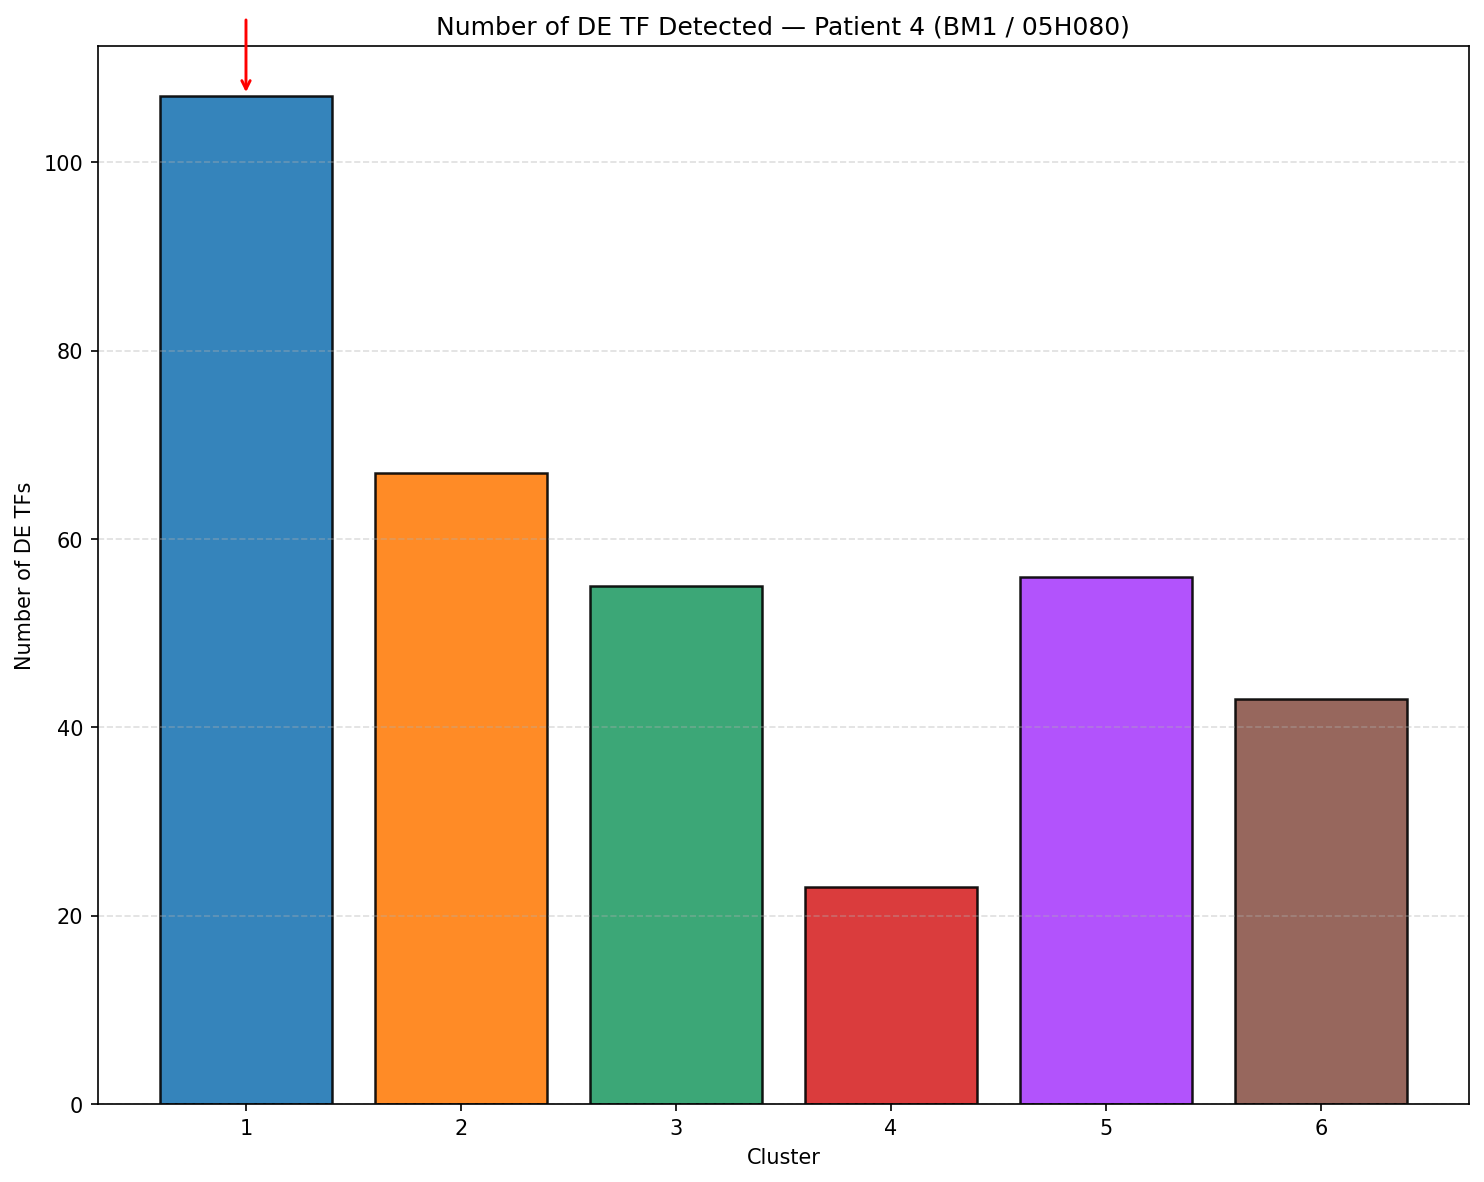

In [1]:
df = pd.read_csv(DATA / "New_Analysis/TotalVI/New/BM1/DE/filtered_rna.csv")
adata_mvi = sc.read_h5ad(DATA / "New_Analysis/Scenicplus/New_BM1/Teaseq_Multi_VI_BM1_Cleaned.h5ad")
plot_de_tf_detected_bar(df, adata_mvi, root="1", title="Number of DE TF Detected")


### b — CSC/Root TF dot plot


50 genes retained


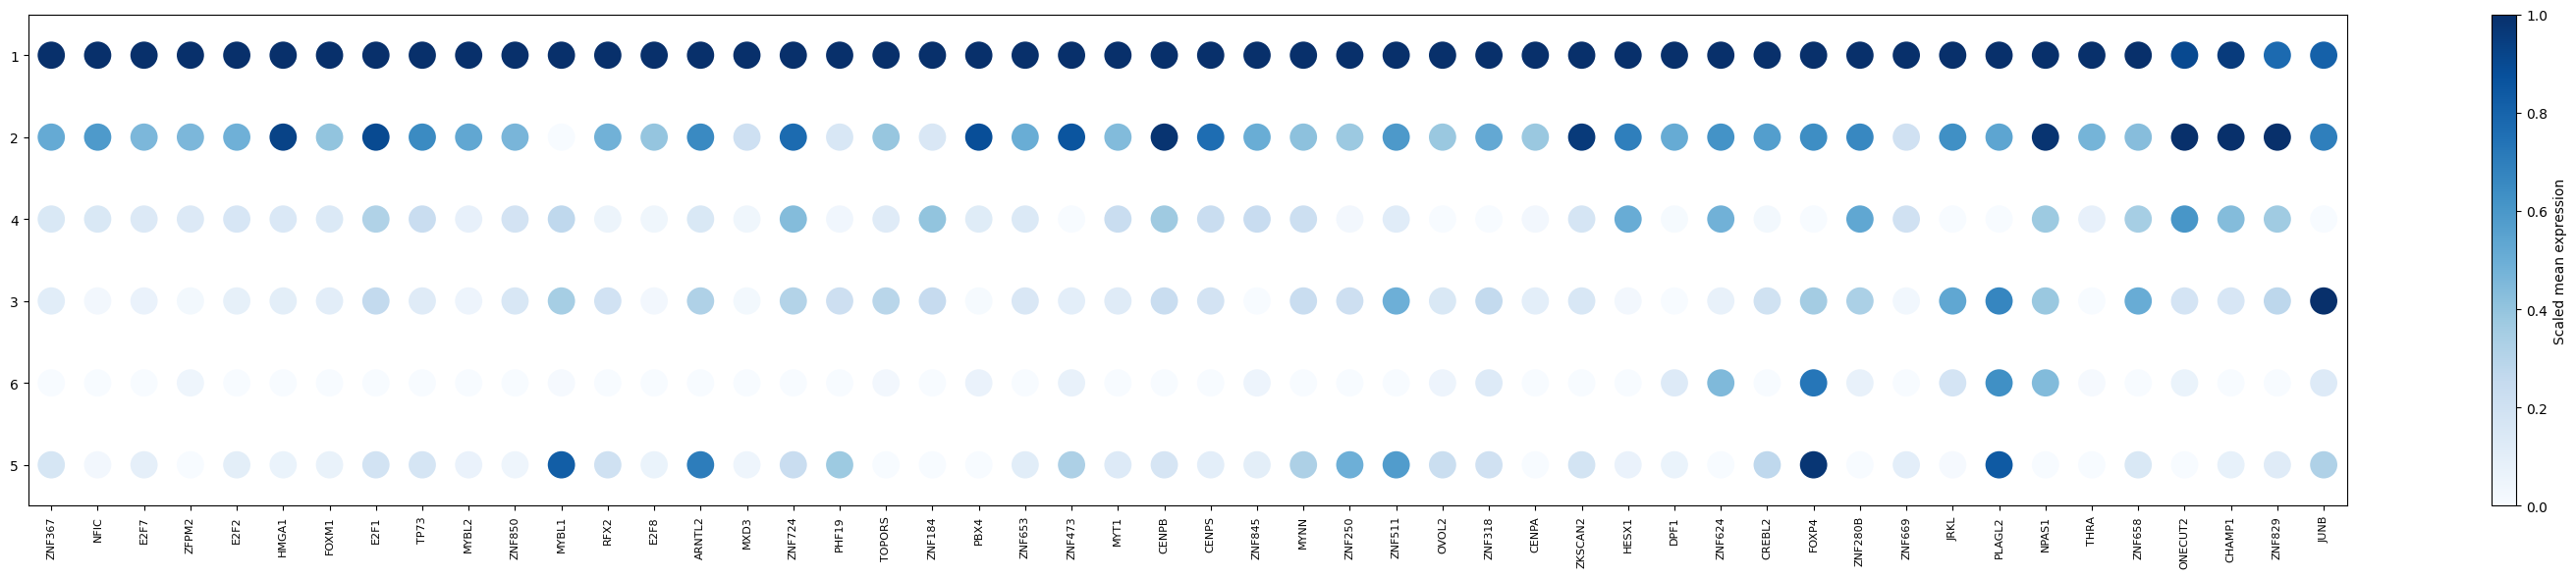

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- cluster order (trajectory, top → bottom on plot) ----
CLUSTER_ORDER = ["1", "2", "4", "3", "6", "5"]

# ---- load genes ----
filtered_rna_df = pd.read_csv(
    "PATH_TO_DATA/TotalVI/New/BM1/DE/filtered_rna.csv"
)

filtered_rna = {
    col: filtered_rna_df[col].dropna().tolist()
    for col in filtered_rna_df.columns
    if col != "Unnamed: 0"
}

# ---- BM1 TF program ----
genes_bm1 = [
    "E2F8", "MYBL2", "ZFPM2", "E2F2", "PBX4", "FOXM1", "E2F7",
    "ZNF367", "MXD3", "HESX1", "TP73", "OVOL2", "ZKSCAN2",
    "ZNF850", "CENPS", "E2F1", "ZNF845", "ZNF669", "ZNF653",
    "MYT1", "CENPA", "HMGA1", "ZNF624", "NFIC", "PHF19",
    "ZNF318", "ZNF280B", "MYBL1", "THRA", "TOPORS", "ONECUT2",
    "RFX2", "CENPB", "DPF1", "ZNF473", "ZNF724", "NPAS1",
    "CHAMP1", "ZNF184", "MYNN", "ZNF250", "ZNF829", "FOXP4",
    "ZNF511", "JUNB", "JRKL", "ZNF658", "CREBL2", "ARNTL2",
    "PLAGL2",
]

# ---- data ----
rna = mdata_bm1.mod["rna_subset"].copy()
rna.X = rna.layers["denoised_rna"]

# ---- keep ONLY genes present in BOTH lists AND dataset ----
genes = filtered_rna["1"]
genes = [g for g in genes if g in genes_bm1 and g in rna.var_names]

print(f"{len(genes)} genes retained")

# ---- matrix ----
X = rna[:, genes].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

groups = rna.obs["leiden_totalVI"].astype(str).values

df = pd.DataFrame(X, columns=genes)
df["group"] = groups

mean = df.groupby("group").mean()
pct = df.drop(columns="group").gt(0).groupby(df["group"]).mean()

# restrict + order clusters
clusters_present = [c for c in CLUSTER_ORDER if c in mean.index.astype(str)]
mean = mean.loc[clusters_present]
pct = pct.loc[clusters_present]

# Scanpy-style scaling
mean_scaled = (mean - mean.min()) / (mean.max() - mean.min() + 1e-9)

# ---- staircase gene order ----
cluster_to_idx = {c: i for i, c in enumerate(CLUSTER_ORDER)}
peak_cluster = mean[genes].idxmax(axis=0)

genes_ordered = sorted(
    genes,
    key=lambda g: (
        cluster_to_idx.get(str(peak_cluster[g]), len(CLUSTER_ORDER)),
        -float(mean.loc[peak_cluster[g], g]),
    ),
)

mean = mean[genes_ordered]
pct = pct[genes_ordered]
mean_scaled = mean_scaled[genes_ordered]

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(max(12, len(genes_ordered) * 0.6), 6))

x_pos = np.arange(len(genes_ordered))

for i, cluster in enumerate(clusters_present):
    ax.scatter(
        x_pos,
        np.full(len(x_pos), i),
        s=pct.loc[cluster].values * 400,
        c=mean_scaled.loc[cluster].values,
        cmap="Blues",
        vmin=0,
        vmax=1,
        edgecolors="none",
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(genes_ordered, rotation=90, fontsize=8)

ax.set_yticks(np.arange(len(clusters_present)))
ax.set_yticklabels(clusters_present)

ax.set_xlim(-0.5, len(genes_ordered) - 0.5)
ax.set_ylim(-0.5, len(clusters_present) - 0.5)
ax.invert_yaxis()  # cluster 1 at the top → diagonal staircase

plt.tight_layout()
plt.show()


## BM3

### a — DE TF counts


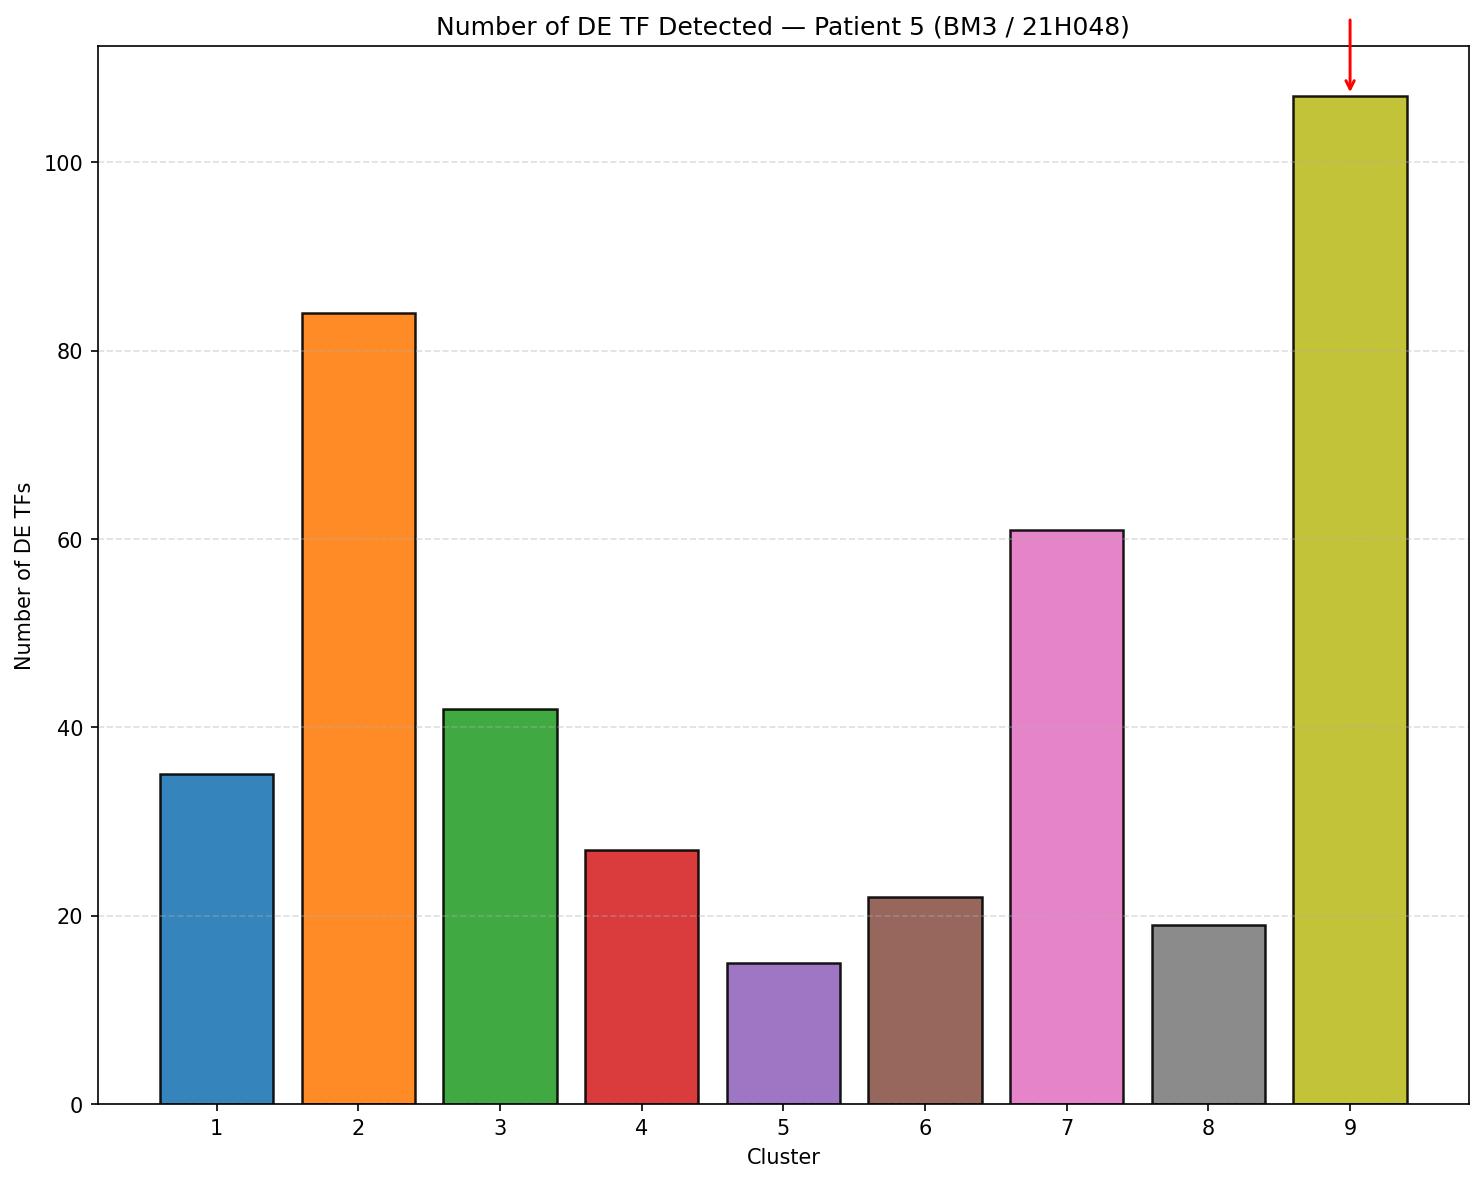

In [1]:
df = pd.read_csv(DATA / "New_Analysis/TotalVI/New/BM3/DE/filtered_rna.csv")
adata_mvi = sc.read_h5ad(DATA / "New_Analysis/Scenicplus/New_BM3/Teaseq_Multi_VI_BM3_Cleaned.h5ad")
plot_de_tf_detected_bar(df, adata_mvi, root="9", title="Number of DE TF Detected")


### b — CSC/Root TF dot plot


50 genes retained


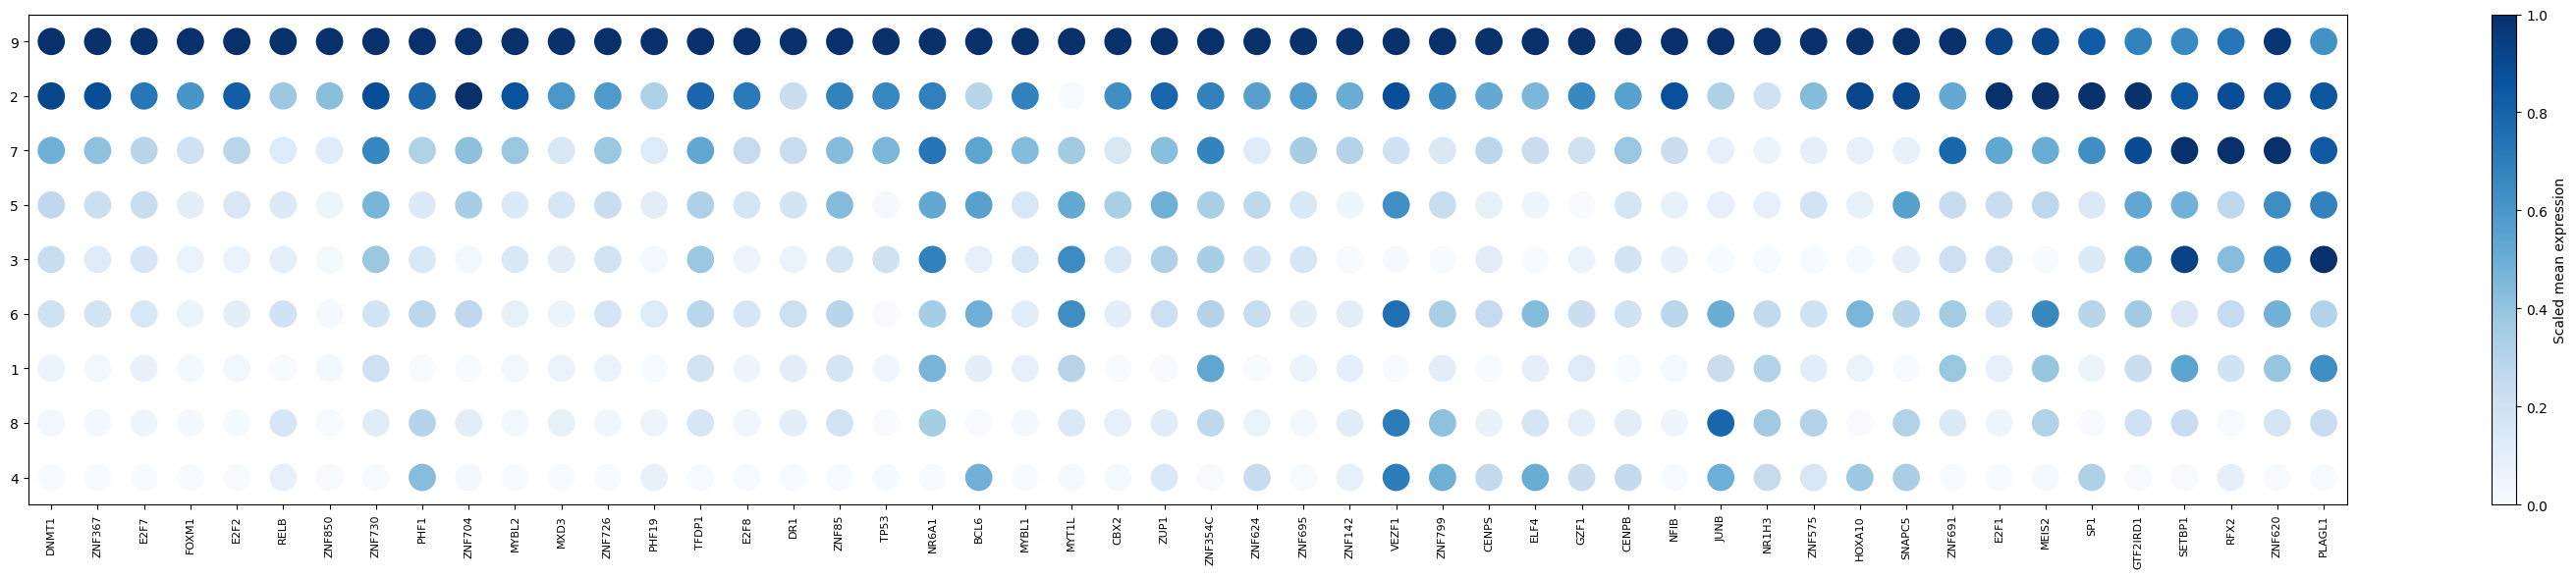

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- cluster order (trajectory, top → bottom on plot) ----
CLUSTER_ORDER = ["9", "2", "7", "5", "3", "6", "1", "8", "4"]

# ---- load genes ----
filtered_rna_df = pd.read_csv(
    "PATH_TO_DATA/TotalVI/New/BM3/DE/filtered_rna.csv"
)

filtered_rna = {
    col: filtered_rna_df[col].dropna().tolist()
    for col in filtered_rna_df.columns
    if col != "Unnamed: 0"
}

# ---- BM3 TF program ----
genes_bm3 = [
    "FOXM1", "E2F2", "MYBL1", "E2F8", "MYBL2", "ZNF850", "ZNF695",
    "E2F1", "PHF19", "MXD3", "ZNF367", "CENPB", "ZNF704", "E2F7",
    "NFIB", "ZNF730", "ZNF726", "DNMT1", "NR1H3", "ZNF691",
    "ZNF575", "RELB", "ELF4", "ZNF85", "ZUP1", "DR1", "ZNF624",
    "CENPS", "GZF1", "ZNF799", "JUNB", "ZNF142", "ZNF620",
    "GTF2IRD1", "ZNF354C", "TP53", "NR6A1", "PHF1", "HOXA10",
    "MYT1L", "TFDP1", "CBX2", "MEIS2", "SNAPC5", "SP1", "RFX2",
    "PLAGL1", "BCL6", "VEZF1", "SETBP1",
]

# ---- data ----
rna = mdata_bm3.mod["rna_subset"].copy()
rna.X = rna.layers["denoised_rna"]

# ---- keep ONLY genes present in BOTH lists AND dataset ----
genes = filtered_rna["9"]
genes = [g for g in genes if g in genes_bm3 and g in rna.var_names]

print(f"{len(genes)} genes retained")

# ---- matrix ----
X = rna[:, genes].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

groups = rna.obs["leiden_totalVI"].astype(str).values

df = pd.DataFrame(X, columns=genes)
df["group"] = groups

mean = df.groupby("group").mean()
pct = df.drop(columns="group").gt(0).groupby(df["group"]).mean()

# restrict + order clusters
clusters_present = [c for c in CLUSTER_ORDER if c in mean.index.astype(str)]
mean = mean.loc[clusters_present]
pct = pct.loc[clusters_present]

# Scanpy-style scaling
mean_scaled = (mean - mean.min()) / (mean.max() - mean.min() + 1e-9)

# ---- staircase gene order ----
cluster_to_idx = {c: i for i, c in enumerate(CLUSTER_ORDER)}
peak_cluster = mean[genes].idxmax(axis=0)

genes_ordered = sorted(
    genes,
    key=lambda g: (
        cluster_to_idx.get(str(peak_cluster[g]), len(CLUSTER_ORDER)),
        -float(mean.loc[peak_cluster[g], g]),
    ),
)

mean = mean[genes_ordered]
pct = pct[genes_ordered]
mean_scaled = mean_scaled[genes_ordered]

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(max(12, len(genes_ordered) * 0.6), 6))

x_pos = np.arange(len(genes_ordered))

for i, cluster in enumerate(clusters_present):
    ax.scatter(
        x_pos,
        np.full(len(x_pos), i),
        s=pct.loc[cluster].values * 400,
        c=mean_scaled.loc[cluster].values,
        cmap="Blues",
        vmin=0,
        vmax=1,
        edgecolors="none",
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(genes_ordered, rotation=90, fontsize=8)

ax.set_yticks(np.arange(len(clusters_present)))
ax.set_yticklabels(clusters_present)

ax.set_xlim(-0.5, len(genes_ordered) - 0.5)
ax.set_ylim(-0.5, len(clusters_present) - 0.5)
ax.invert_yaxis()  # cluster 9 at the top → diagonal staircase

plt.tight_layout()
plt.show()
